# Low-Light Image Restoration with DarkIR model using OpenVINO™

[DarkIR](https://arxiv.org/abs/2412.13443) is an CNN model for Low-Light Image Restoration.

Photography during night or in dark conditions typically suffers from noise, low light and blurring issues due to the dim environment and the common use of long exposure. Although Deblurring and Low-light Image Enhancement (LLIE) are related under these conditions, most approaches in image restoration solve these tasks separately. DarkIR is an efficient and robust neural network for multi-task low-light image restoration. This approach proposes new attention mechanisms to enhance the receptive field of efficient CNNs. Current method reduces the computational costs in terms of parameters and MAC operations compared to previous methods. DarkIR achieves new state-of-the-art results on the popular LOLBlur, LOLv2 and Real-LOLBlur datasets, being able to generalize on real-world night and dark images.

![networks-scheme](https://raw.githubusercontent.com/cidautai/DarkIR/refs/heads/main/assets/networks-scheme.png)

[**image_source*](https://github.com/cidautai/DarkIR/blob/main/assets/networks-scheme.png)

You can find more information about this model in the [research paper](https://arxiv.org/abs/2412.13443) and GitHub [repository](https://github.com/cidautai/DarkIR).


The notebook contains the following steps:

1. Prepare the PyTorch model.
2. Prepare data and perform inference of the PyTorch model with image.
3. Convert model to OpenVINO IR, using the model conversion API.
4. Run inference with OpenVINO with image and video.
5. Quantize the converted model with NNCF.
6. Check the quantized model inference result.
7. Compare model size of converted and quantized models.
8. Compare performance of converted and quantized models.
9. Launch interactive demo


### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).




<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/lol-image-restoration-darkir/lol-image-restoration-darkir.ipynb" />

#### Table of contents:

- [Prerequisites](#Prerequisites)
- [Run PyTorch model inference](#Run-PyTorch-model-inference)
    - [Prepare model](#Prepare-model)
    - [Prepare data](#Prepare-data)
    - [Perform inference on image](#Perform-inference-on-image)
- [Run OpenVINO model](#Run-OpenVINO-model)
    - [Select inference device](#Select-inference-device)
    - [Convert model](#Convert-model)
    - [Compile model and perform inference on image](#Compile-model-and-perform-inference-on-image)
    - [Perform inference on video](#Perform-inference-on-video)
- [Quantize model to INT8 using NNCF](#Quantize-model-to-INT8-using-NNCF)
    - [Prepare datasets](#Prepare-datasets)
    - [Perform quantization](#Perform-quantization)
    - [Run quantized OpenVINO model](#Run-quantized-OpenVINO-model)
    - [Compare File Size](#Compare-File-Size)
    - [Compare inference time of the FP16 IR and quantized models](#Compare-inference-time-of-the-FP16-IR-and-quantized-models)
- [Interactive demo](#Interactive-demo)



## Prerequisites
[back to top ⬆️](#Table-of-contents:)

Install required dependencies

In [1]:
%pip install -q --extra-index-url https://download.pytorch.org/whl/cpu "gradio>=4.19" "matplotlib>=3.4" "nncf>=2.16.0" Pillow ptflops torchvision "torch>=2.1" numpy opencv-python "datasets>=2.14.6" huggingface_hub[cli]

%pip install --pre openvino==2025.2.0.* --extra-index-url=https://storage.openvinotoolkit.org/simple/wheels/nightly

from pathlib import Path
import requests
import platform

if platform.system() == "Darwin":
    %pip install "numpy<2.0"

if not Path("notebook_utils.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py",
    )
    open("notebook_utils.py", "w").write(r.text)

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("lol-image-restoration-darkir.ipynb")

Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://pypi.org/simple, https://storage.openvinotoolkit.org/simple/wheels/nightly
Note: you may need to restart the kernel to use updated packages.


## Run PyTorch model inference
[back to top ⬆️](#Table-of-contents:)

### Prepare model
[back to top ⬆️](#Table-of-contents:)


At first, we clone the [DarkIR](https://github.com/cidautai/DarkIR) repo and load checkpoint. There are several model options, you can find variants [here](https://cidautes-my.sharepoint.com/personal/alvgar_cidaut_es/_layouts/15/onedrive.aspx?id=%2Fpersonal%2Falvgar%5Fcidaut%5Fes%2FDocuments%2FCidautAI%2FWorks%2FDarkIR%2Fmodels&ga=1), but we download `DarkIR_384.pt` from [HuggingFace Hub](https://huggingface.co/Cidaut/DarkIR) via [`huggingface-cli`](https://huggingface.co/docs/huggingface_hub/main/en/guides/cli). Then we create the model instance with `DarkIR` API and load weights.

In [2]:
!git clone https://github.com/cidautai/DarkIR.git

fatal: destination path 'DarkIR' already exists and is not an empty directory.


In [3]:
from pathlib import Path

model_checkpoints_path = Path("DarkIR/models")
model_id = "Cidaut/DarkIR"

!huggingface-cli download {model_id} --local-dir {model_checkpoints_path.as_posix()}

Fetching 3 files: 100%|█████████████████████████| 3/3 [00:00<00:00, 5748.25it/s]
/home/labuser/work/notebook/openvino_notebooks/notebooks/lol-image-restoration-darkir/DarkIR/models


In [4]:
import sys
import torch

sys.path.append("DarkIR")

from archs.DarkIR import DarkIR


def load_model(model, path_weights):
    map_location = "cpu"
    checkpoints = torch.load(path_weights, map_location=map_location, weights_only=False)

    weights = checkpoints["params"]
    weights = {key: value for key, value in weights.items()}

    model.load_state_dict(weights)
    return model


model = DarkIR()
model.to("cpu")

model_path = Path(model_checkpoints_path, "DarkIR_384.pt")

model = load_model(model, path_weights=model_path.resolve().as_posix())
model.eval()

DarkIR(
  (intro): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (ending): Conv2d(32, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (encoders): ModuleList(
    (0): CustomSequential(
      (modules_list): ModuleList(
        (0): EBlock(
          (extra_conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32)
          (conv1): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
          (branches): ModuleList(
            (0): Branch(
              (branch): Sequential(
                (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64)
              )
            )
          )
          (sca): Sequential(
            (0): AdaptiveAvgPool2d(output_size=1)
            (1): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
          )
          (sg1): SimpleGate()
          (conv3): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
          (norm1): LayerNorm2d()
          (norm2): LayerNorm2d()
   

### Prepare data
[back to top ⬆️](#Table-of-contents:)


To perform low-light image restoration, we need to prepare image tensor. Let's prepare function, which present the image as float32 array, transpose axes and expand the shape of that array.

In [5]:
import cv2

import numpy as np
import torch.nn.functional as F


def pad_tensor(tensor: torch.Tensor, multiple=8):
    """pad the tensor to be multiple of some number"""
    multiple = multiple
    _, _, H, W = tensor.shape
    pad_h = (multiple - H % multiple) % multiple
    pad_w = (multiple - W % multiple) % multiple

    tensor = F.pad(tensor, (0, pad_w, 0, pad_h), value=0)

    return tensor


def prepare_input_data(image):
    img = np.array(image)
    img = image / 255.0
    img = img.astype(np.float32)

    tensor = torch.tensor(img).permute(2, 0, 1).unsqueeze(0)
    tensor = pad_tensor(tensor)

    return tensor


def normalize_minmax(data):
    """Normalizes the values in `data` between 0 and 1"""
    return (data - data.min()) / (data.max() - data.min())


def tune_output(output_tensor: np.array):
    output = np.squeeze(output_tensor, 0)
    output = np.transpose(output, (1, 2, 0))
    output = normalize_minmax(output)
    output = (output * 255).astype(np.uint8)
    output = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)  # flip red and blue channels
    return output

In [6]:
from pathlib import Path

demo_image_path = Path("./DarkIR/assets/qualis/inputs/0010.png")

image = cv2.imread(demo_image_path)

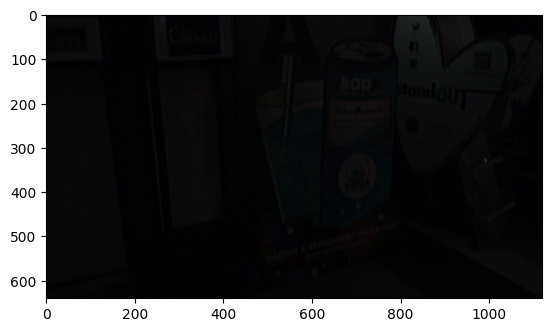

In [7]:
import matplotlib.pyplot as plt

plt.imshow(image)
plt.show()

## Perform inference on image
[back to top ⬆️](#Table-of-contents:)

In [8]:
tensor = prepare_input_data(image)

with torch.no_grad():
    output = model(tensor, side_loss=False)

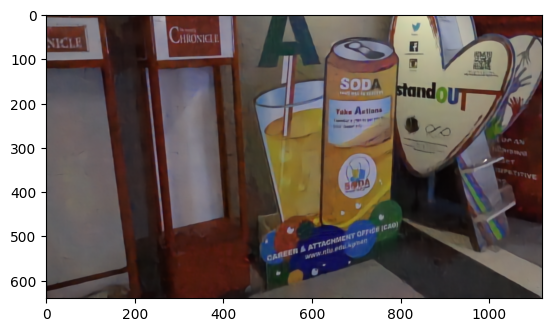

In [9]:
import matplotlib.pyplot as plt

output_img = tune_output(output.cpu().numpy())
plt.imshow(output_img)
plt.show()

## Run OpenVINO model
[back to top ⬆️](#Table-of-contents:)

In [10]:
import openvino as ov

# create OpenVINO core object instance
core = ov.Core()

### Select inference device
[back to top ⬆️](#Table-of-contents:)

Select device from dropdown list for running inference using OpenVINO

In [11]:
from notebook_utils import device_widget

device = device_widget()

device

Dropdown(description='Device:', index=1, options=('CPU', 'AUTO'), value='AUTO')

### Convert model
[back to top ⬆️](#Table-of-contents:)


Convert the PyTorch model to OpenVINO IR. An OpenVINO IR (Intermediate Representation) model consists of an `.xml` file, containing information about network topology, and a `.bin` file, containing the weights and biases binary data. Model conversion Python API is used for conversion of the model to OpenVINO IR. The `ov.convert_model` Python function returns an OpenVINO model ready to load on a device and start making predictions. We can save it on a disk for next usage with `ov.save_model`. For more information about model conversion Python API, see this [page](https://docs.openvino.ai/2024/openvino-workflow/model-preparation.html).

We specify `example_input` for convert_model based on the implementation details of DarkIR model. It contains tree elements, that correspond to the input parameters of the `forward`: `input` - image tensor, `side_loss` and `use_adapter` - boolean parameters, we replace them with a scalar tensor.

In [12]:
ov_model_path = Path("ov_model", "model.xml")

converted_model = ov.convert_model(model, example_input=(torch.zeros([1, 3, 256, 256]), torch.tensor(0), torch.tensor(0)))
ov.save_model(converted_model, ov_model_path)

/home/labuser/work/notebook/openvino_notebooks/notebooks/lol-image-restoration-darkir/DarkIR/archs/DarkIR.py:90: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if side_loss:
/home/labuser/work/notebook/openvino_notebooks/notebooks/lol-image-restoration-darkir/DarkIR/archs/DarkIR.py:104: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if side_loss:


### Compile model and perform inference on image
[back to top ⬆️](#Table-of-contents:)


The steps for making predictions with the OpenVINO model are similar to the PyTorch model. Let us check the model result using the same input data from the example above with PyTorch.

In [13]:
compiled_model = ov.compile_model(converted_model, device.value)

In [14]:
indut_data = [tensor, torch.tensor(0), torch.tensor(0)]

ov_res = compiled_model(indut_data)

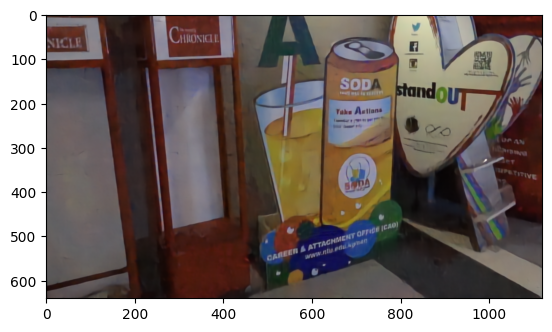

In [15]:
import numpy as np
import matplotlib.pyplot as plt

output_img = tune_output(ov_res[0])
plt.imshow(output_img)
plt.show()

### Perform inference on video
[back to top ⬆️](#Table-of-contents:)

In [16]:
from notebook_utils import download_file

if not Path("Coco Walking in Berkeley.mp4").exists():
    download_file(
        "https://storage.openvinotoolkit.org/repositories/openvino_notebooks/data/data/video/Coco%20Walking%20in%20Berkeley.mp4",
        "./Coco Walking in Berkeley.mp4",
    )

VIDEO_FILE = "./Coco Walking in Berkeley.mp4"
# Number of seconds of input video to process. Set `NUM_SECONDS` to 0 to process
# the full video.
NUM_SECONDS = 2
# Set `ADVANCE_FRAMES` to 1 to process every frame from the input video
# Set `ADVANCE_FRAMES` to 2 to process every second frame. This reduces
# the time it takes to process the video.
ADVANCE_FRAMES = 2
# Set `SCALE_OUTPUT` to reduce the size of the result video
# If `SCALE_OUTPUT` is 0.5, the width and height of the result video
# will be half the width and height of the input video.
SCALE_OUTPUT = 0.5
# The format to use for video encoding. The 'vp09` is slow,
# but it works on most systems.
# Try the `THEO` encoding if you have FFMPEG installed.
# FOURCC = cv2.VideoWriter_fourcc(*"THEO")
FOURCC = cv2.VideoWriter_fourcc(*"vp09")

# Create Path objects for the input video and the result video.
output_directory = Path("output")
output_directory.mkdir(exist_ok=True)
result_video_path = output_directory / f"{Path(VIDEO_FILE).stem}_darkir.mp4"

In [17]:
import time
from IPython.display import (
    HTML,
    FileLink,
    Pretty,
    ProgressBar,
    Video,
    clear_output,
    display,
)


def process_video(compiled_model, video_file, result_video_path):
    # Initialize variables.
    input_video_frame_nr = 0
    start_time = time.perf_counter()
    total_inference_duration = 0

    # Open the input video
    cap = cv2.VideoCapture(str(video_file))

    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))

    # Create a result video.
    out_video = cv2.VideoWriter(
        str(result_video_path),
        FOURCC,
        fps,
        (frame_width * 2, frame_height),
    )

    num_frames = int(NUM_SECONDS * fps)
    total_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT) if num_frames == 0 else num_frames
    progress_bar = ProgressBar(total=total_frames)
    progress_bar.display()

    try:
        while cap.isOpened():
            ret, image = cap.read()
            old_frame = np.copy(image)
            if not ret:
                cap.release()
                break

            if input_video_frame_nr >= total_frames:
                break

            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            tensor_image = prepare_input_data(image)
            indut_data = [tensor_image, torch.tensor(0), torch.tensor(0)]

            inference_start_time = time.perf_counter()
            output = compiled_model(indut_data)
            inference_stop_time = time.perf_counter()
            inference_duration = inference_stop_time - inference_start_time
            total_inference_duration += inference_duration

            frame = tune_output(output[0])
            combined = np.hstack((old_frame, frame))
            if input_video_frame_nr % (10 * ADVANCE_FRAMES) == 0:
                clear_output(wait=True)
                progress_bar.display()
                # input_video_frame_nr // ADVANCE_FRAMES gives the number of
                # Frames that have been processed by the network.
                display(
                    Pretty(
                        f"Processed frame {input_video_frame_nr // ADVANCE_FRAMES}"
                        f"/{total_frames // ADVANCE_FRAMES}. "
                        f"Inference time per frame: {inference_duration:.2f} seconds "
                        f"({1/inference_duration:.2f} FPS)"
                    )
                )

            out_video.write(combined)

            input_video_frame_nr = input_video_frame_nr + ADVANCE_FRAMES
            cap.set(1, input_video_frame_nr)

            progress_bar.progress = input_video_frame_nr
            progress_bar.update()

    except KeyboardInterrupt:
        print("Processing interrupted.")
    finally:
        clear_output()
        processed_frames = num_frames // ADVANCE_FRAMES
        out_video.release()
        cap.release()
        end_time = time.perf_counter()
        duration = end_time - start_time

        print(
            f"Processed {processed_frames} frames in {duration:.2f} seconds. "
            f"Total FPS (including video processing): {processed_frames/duration:.2f}."
            f"Inference FPS: {processed_frames/total_inference_duration:.2f} "
        )
        print(f"Video saved to '{str(result_video_path)}'.")
    return combined

In [18]:
stacked_frame = process_video(compiled_model, VIDEO_FILE, result_video_path)

Processed 30 frames in 28.61 seconds. Total FPS (including video processing): 1.05.Inference FPS: 1.56 
Video saved to 'output/Coco Walking in Berkeley_darkir.mp4'.


In [19]:
def display_video(stacked_frame):
    video = Video(result_video_path, width=800, embed=True)
    if not result_video_path.exists():
        plt.imshow(stacked_frame)
        raise ValueError("OpenCV was unable to write the video file. Showing one video frame.")
    else:
        print(f"Showing video saved at\n{result_video_path.resolve()}")
        print("If you cannot see the video in your browser, please click on the " "following link to download the video ")
        video_link = FileLink(result_video_path)
        video_link.html_link_str = "<a href='%s' download>%s</a>"
        display(HTML(video_link._repr_html_()))
        display(video)

In [20]:
display_video(stacked_frame)

Showing video saved at
/home/labuser/work/notebook/openvino_notebooks/notebooks/lol-image-restoration-darkir/output/Coco Walking in Berkeley_darkir.mp4
If you cannot see the video in your browser, please click on the following link to download the video 


## Quantize model to INT8 using NNCF
[back to top ⬆️](#Table-of-contents:)

The goal of this part of tutorial is to demonstrate how to speed up the model by applying 8-bit post-training quantization from [NNCF](https://github.com/openvinotoolkit/nncf/) (Neural Network Compression Framework) and infer quantized model via OpenVINO™ Toolkit. 
[NNCF](https://github.com/openvinotoolkit/nncf/) enables post-training quantization by adding quantization layers into model graph and then using a subset of the training dataset to initialize the parameters of these additional quantization layers. Quantized operations are executed in `INT8` instead of `FP32`/`FP16` making model inference faster.
The optimization process contains the following steps:

1. Prepare quantization dataset
2. Quantize the converted OpenVINO model with NNCF.
3. Check the model result using the same input data like we use.
4. Compare model size of converted and quantized models.
5. Compare performance of converted and quantized models.

> **Note:** quantization process may require additional time and memory for performing. You can disable it using widget below:

In [21]:
from notebook_utils import quantization_widget

to_quantize = quantization_widget()

to_quantize

Checkbox(value=True, description='Quantization')

In [22]:
# Fetch skip_kernel_extension module
if not Path("skip_kernel_extension.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/skip_kernel_extension.py",
    )
    open("skip_kernel_extension.py", "w").write(r.text)

%load_ext skip_kernel_extension

### Prepare datasets
[back to top ⬆️](#Table-of-contents:)

We will use [LOL Dataset](https://huggingface.co/datasets/geekyrakshit/LoL-Dataset). It is composed of 500 low-light and normal-light image pairs and is divided into 485 training pairs and 15 testing pairs. The low-light images contain noise produced during the photo capture process. Most of the images are indoor scenes. All the images have a resolution of 400×600. The dataset was introduced in the paper [Deep Retinex Decomposition for Low-Light Enhancement](https://arxiv.org/abs/1808.04560v1).

In [50]:
%%skip not $to_quantize.value

import requests
from io import BytesIO
import numpy as np
from PIL import Image
from requests.packages.urllib3.exceptions import InsecureRequestWarning
requests.packages.urllib3.disable_warnings(InsecureRequestWarning)


def get_pil_from_url(url):
    """
    Downloads and converts an image from a URL to a PIL Image object.
    """
    print(url)
    response = requests.get(url, verify=False, timeout=20)
    image = Image.open(BytesIO(response.content)).convert("RGB")
    return np.asarray(image)

def collate_image_fn(example):
    """
    Preprocesses an example by loading and transforming image and text data.
    Checks if the text data in the example is valid by calling the `check_text_data` function.
    Downloads the image specified by the URL in the image_column by calling the `get_pil_from_url` function.
    If there is any error during the download process, returns None.
    Returns the preprocessed inputs with transformed image and text data.
    """
    assert len(example) == 1
    image = np.asarray(example[0]['image'])
    inputs = prepare_input_data(image)
    return [inputs, torch.tensor(0), torch.tensor(0)]

In [44]:
%%skip not $to_quantize.value

import torch
import datasets
from tqdm.notebook import tqdm

def prepare_image_calibration_data(dataloader, init_steps):
    """
    This function prepares calibration data from a dataloader for a specified number of initialization steps.
    It iterates over the dataloader, fetching batches and storing the relevant data.
    """
    data = []
    print(f"Fetching {init_steps} samples for the initialization...")
    with tqdm(total=init_steps) as pbar:
        for batch in dataloader:
            if len(data) == init_steps:
                break
            if batch is not None:
                pbar.update(1)
                data.append(batch)

    return data
    

def prepare_dataset(opt_init_steps=70, max_train_samples=1000, text_data=True):
    """
    Prepares a vision-text dataset for quantization.
    """
    dataset = datasets.load_dataset("geekyrakshit/LoL-Dataset", streaming=True)
    train_dataset = dataset['train'].shuffle(seed=42)
    dataloader = torch.utils.data.DataLoader(train_dataset, collate_fn=collate_image_fn, batch_size=1)
    calibration_data = prepare_image_calibration_data(dataloader, opt_init_steps)
    return calibration_data

In [ ]:
%%skip not $to_quantize.value

import logging
import nncf

core = ov.Core()

nncf.set_log_level(logging.ERROR)

int8_model_path = Path('quantized', 'openvino_model_int8.xml')
calibration_data = prepare_dataset()

In [52]:
ov_fp16_model = core.read_model(ov_model_path)

### Perform quantization
[back to top ⬆️](#Table-of-contents:)

Create a quantized model from the pre-trained `FP16` model.

> **NOTE**: Quantization is time and memory consuming operation. Running quantization code below may take a long time.

In [ ]:
%%skip not $to_quantize.value

if len(calibration_data) == 0:
    raise RuntimeError(
        'Calibration dataset is empty. Please check internet connection and try to download images manually.'
    )

calibration_dataset = nncf.Dataset(calibration_data)
quantized_model = nncf.quantize(
    model=ov_fp16_model,
    calibration_dataset=calibration_dataset,
    # Smooth Quant algorithm reduces activation quantization error; optimal alpha value was obtained through grid search
    advanced_parameters=nncf.AdvancedQuantizationParameters(smooth_quant_alpha=0.7),
)

ov.save_model(quantized_model, int8_model_path)

### Run quantized OpenVINO model
[back to top ⬆️](#Table-of-contents:)

The steps for making predictions with the quantized OpenVINO model are similar to the PyTorch model. Let us check the model result using the same input data that we used before.

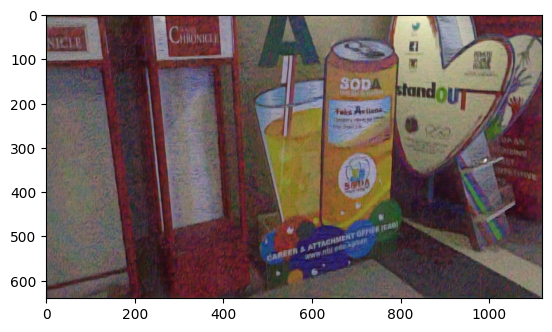

In [54]:
%%skip not $to_quantize.value

import numpy as np
import matplotlib.pyplot as plt

indut_data = [tensor, torch.tensor(0), torch.tensor(0)]

compiled_quantized_model = core.compile_model(int8_model_path, device.value)

quantized_res = compiled_quantized_model(indut_data)
output_img = tune_output(quantized_res[0])
plt.imshow(output_img)
plt.show()

### Compare File Size
[back to top ⬆️](#Table-of-contents:)

In [55]:
%%skip not $to_quantize.value

from pathlib import Path

fp16_model_size = ov_model_path.with_suffix(".bin").stat().st_size / 1024 / 1024
quantized_model_size = int8_model_path.with_suffix(".bin").stat().st_size / 1024 / 1024
print(f"FP16 IR model size: {fp16_model_size:.2f} MB")
print(f"INT8 model size: {quantized_model_size:.2f} MB")
print(f"Model compression rate: {fp16_model_size / quantized_model_size:.3f}")

FP16 IR model size: 6.32 MB
INT8 model size: 3.34 MB
Model compression rate: 1.894


### Compare inference time of the FP16 IR and quantized models
[back to top ⬆️](#Table-of-contents:)
To measure the inference performance of the `FP16` and `INT8` models, we use median inference time on calibration dataset.
So we can approximately estimate the speed up of the dynamic quantized models.


> **NOTE**: For the most accurate performance estimation, it is recommended to run `benchmark_app` in a terminal/command prompt after closing other applications with static shapes.

In [56]:
%%skip not $to_quantize.value

import time

def calculate_inference_time(model_path, calibration_data):
    model = core.compile_model(model_path, device.value)
    inference_time = []
    for bratch in calibration_data:
        start = time.perf_counter()
        _ = model(bratch)[0]
        end = time.perf_counter()
        delta = end - start
        inference_time.append(delta)
    return np.median(inference_time)

In [57]:
%%skip not $to_quantize.value

fp16_latency = calculate_inference_time(ov_model_path, calibration_data)
int8_latency = calculate_inference_time(int8_model_path, calibration_data)
print(f"Performance speed up for model: {fp16_latency / int8_latency:.3f}")

Performance speed up for model: 1.209


## Interactive demo
[back to top ⬆️](#Table-of-contents:)

Now, it is your turn! You can provide your own image for low-light image restoration.

In [58]:
from PIL import Image


def process_img(image):
    img = np.array(image)
    img = img / 255.0
    img = img.astype(np.float32)
    y = torch.tensor(img).permute(2, 0, 1).unsqueeze(0).to("cpu")

    x_hat = compiled_model([y, torch.tensor(0), torch.tensor(0)])

    restored_img = torch.from_numpy(x_hat[0]).squeeze().permute(1, 2, 0).clamp_(0, 1).cpu().detach().numpy()
    restored_img = np.clip(restored_img, 0.0, 1.0)

    restored_img = (restored_img * 255.0).round().astype(np.uint8)
    return Image.fromarray(restored_img)

In [ ]:
if not Path("gradio_helper.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/notebooks/lol-image-restoration-darkir/gradio_helper.py")
    open("gradio_helper.py", "w").write(r.text)

from gradio_helper import make_demo

demo = make_demo(process_img)

try:
    demo.launch(debug=True)
except Exception:
    demo.launch(share=True, debug=True)
# if you are launching remotely, specify server_name and server_port
# demo.launch(server_name='your server name', server_port='server port in int')
# Read more in the docs: https://gradio.app/docs/